# 11 - Training CNN Transfer Learning (ResNet18 - 7 Class)

Menggunakan ResNet18 pretrained ImageNet sebagai feature extractor, fine-tune untuk pengenalan emosi. Dibandingkan dengan CNN from scratch (notebook 01).

**3 Skenario Imbalance:**
- B1: Tanpa penanganan (baseline)
- B2: Dengan class weights (Cui et al., 2019)
- B3: Dengan class weights + augmentasi

## 1. Setup

In [1]:
import sys
import os
import json
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path

# Add project root to path
PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from training.models import EmotionCNNTransfer
from training.utils import (
    EmotionImageDataset, get_class_weights,
    train_model, full_evaluation,
    plot_training_history, plot_confusion_matrix, plot_per_class_f1
)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: Tesla T4
Memory: 15.6 GB


## 2. Config

In [2]:
# Config
DATASET_DIR = PROJECT_ROOT / "data" / "dataset"
DATASET_AUG_DIR = PROJECT_ROOT / "data" / "dataset_augmented"
OUTPUT_DIR = PROJECT_ROOT / "models" / "cnn_transfer"
os.makedirs(OUTPUT_DIR, exist_ok=True)

BATCH_SIZE = 32
EPOCHS = 50
LR = 0.00005  # Smaller LR for fine-tuning pretrained model
PATIENCE = 15
NUM_CLASSES = 7

EMOTIONS = ["neutral", "happy", "sad", "angry", "fearful", "disgusted", "surprised"]
print(f"Dataset: {DATASET_DIR}")
print(f"Output: {OUTPUT_DIR}")
print(f"Learning Rate: {LR} (fine-tuning)")

Dataset: /home/bs000716/MOTHER-TANK/TRAIN/data/dataset
Output: /home/bs000716/MOTHER-TANK/TRAIN/models/cnn_transfer
Learning Rate: 5e-05 (fine-tuning)


## 3. Load Data

In [3]:
from torch.utils.data import DataLoader
from collections import Counter

def load_dataloaders(dataset_dir, batch_size=32):
    """Load train/val/test dataloaders."""
    train_ds = EmotionImageDataset(
        dataset_dir / "X_train_images.npy",
        dataset_dir / "y_train.npy"
    )
    val_ds = EmotionImageDataset(
        dataset_dir / "X_val_images.npy",
        dataset_dir / "y_val.npy"
    )
    test_ds = EmotionImageDataset(
        dataset_dir / "X_test_images.npy",
        dataset_dir / "y_test.npy"
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    # Print info
    y_train = np.load(dataset_dir / "y_train.npy")
    counts = Counter(y_train.tolist())
    print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
    print(f"Train distribution:")
    for i, emo in enumerate(EMOTIONS):
        print(f"  {emo:>10s}: {counts.get(i, 0)}")

    return train_loader, val_loader, test_loader

# Load original dataset
train_loader, val_loader, test_loader = load_dataloaders(DATASET_DIR, BATCH_SIZE)

Train: 7064 | Val: 1174 | Test: 1656
Train distribution:
     neutral: 5678
       happy: 751
         sad: 490
       angry: 48
     fearful: 8
   disgusted: 19
   surprised: 70


## 4. Skenario B1: Baseline (Tanpa Class Weights)

In [4]:
# B1: Baseline - no class weights
model_b1 = EmotionCNNTransfer(num_classes=NUM_CLASSES, pretrained=True).to(device)
criterion_b1 = nn.CrossEntropyLoss()
optimizer_b1 = torch.optim.Adam(model_b1.parameters(), lr=LR)
scheduler_b1 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_b1, mode="max", factor=0.5, patience=8, min_lr=1e-7
)

print(f"Model parameters: {sum(p.numel() for p in model_b1.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model_b1.parameters() if p.requires_grad):,}")
print("Training B1 (baseline)...")
history_b1, best_epoch_b1 = train_model(
    model_b1, train_loader, val_loader, criterion_b1, optimizer_b1, scheduler_b1,
    device, model_type="cnn", epochs=EPOCHS, patience=PATIENCE,
    save_path=str(OUTPUT_DIR / "cnn_tl_b1_baseline.pth")
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


  0%|          | 0.00/44.7M [00:00<?, ?B/s]

  4%|▎         | 1.62M/44.7M [00:00<00:02, 16.6MB/s]

 13%|█▎        | 5.88M/44.7M [00:00<00:01, 31.4MB/s]

 28%|██▊       | 12.4M/44.7M [00:00<00:00, 47.3MB/s]

...

    20      0.0093     0.9990     0.3102    0.9225   0.2187   0.000025  (24.1s)


    21      0.0085     0.9994     0.3001    0.9225   0.2231   0.000025  (24.1s)


    22      0.0056     1.0000     0.3076    0.9216   0.2141   0.000025  (24.1s)


    23      0.0048     1.0000     0.3000    0.9267   0.2317   0.000025  (24.1s)


    24      0.0049     1.0000     0.2913    0.9284   0.2299   0.000025  (24.2s)

Early stopping at epoch 24. Best epoch: 9 (val_f1=0.2452)

Best: epoch 9, val_acc=0.9157, val_f1=0.2452
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/cnn_transfer/cnn_tl_b1_baseline.pth


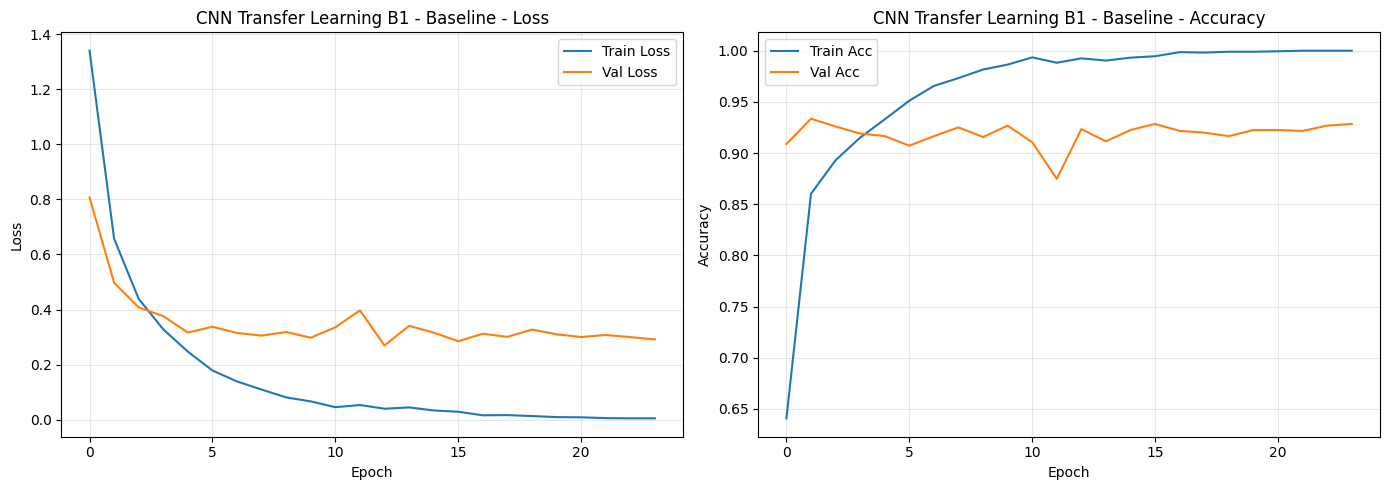

EVALUASI B1 - BASELINE


Test Loss: 0.2459
Test Accuracy: 0.9499
Test Macro F1: 0.1458
Test Weighted F1: 0.9353

Classification Report:
              precision    recall  f1-score   support

     neutral       0.96      0.99      0.97      1588
       happy       0.00      0.00      0.00        10
         sad       0.20      0.03      0.05        38
       angry       0.00      0.00      0.00        13
     fearful       0.00      0.00      0.00         1
   disgusted       0.00      0.00      0.00         3
   surprised       0.00      0.00      0.00         3

    accuracy                           0.95      1656
   macro avg       0.17      0.15      0.15      1656
weighted avg       0.92      0.95      0.94      1656



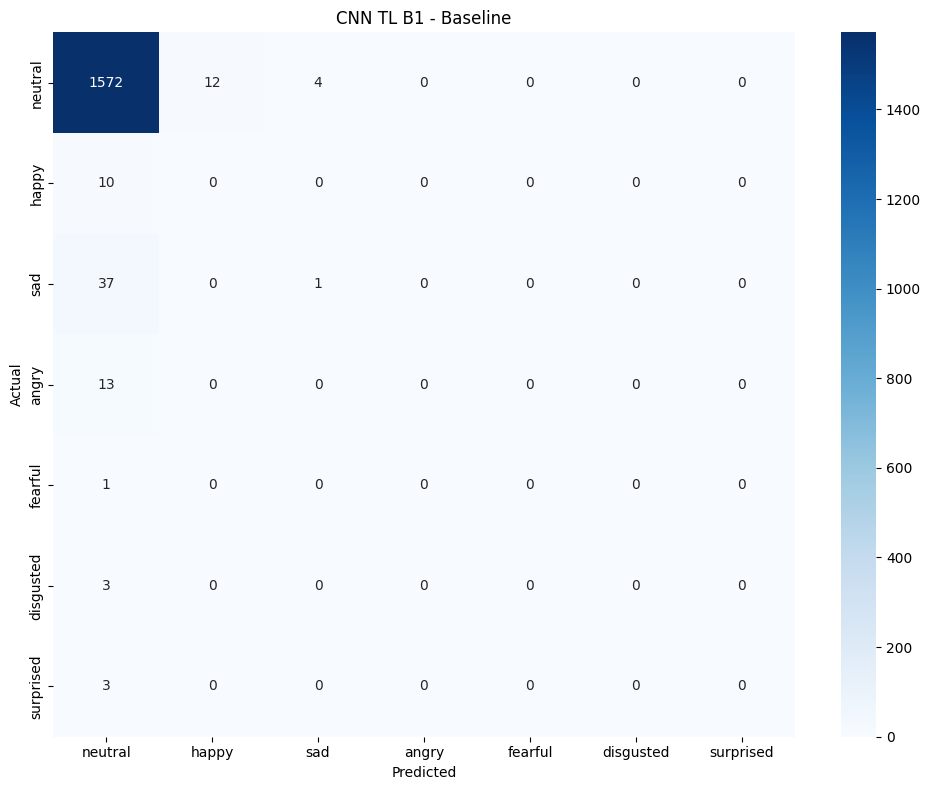

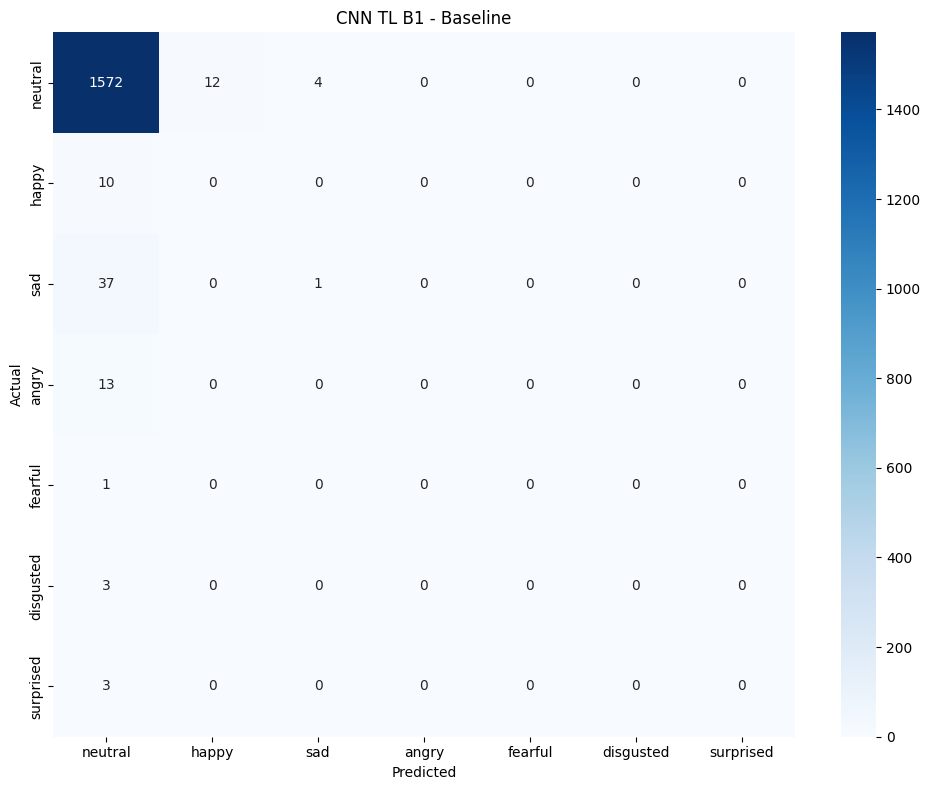

In [5]:
plot_training_history(history_b1, "CNN Transfer Learning B1 - Baseline")

print("=" * 60)
print("EVALUASI B1 - BASELINE")
print("=" * 60)
results_b1 = full_evaluation(model_b1, test_loader, criterion_b1, device, "cnn")
plot_confusion_matrix(results_b1["confusion_matrix"], "CNN TL B1 - Baseline")

## 5. Skenario B2: Dengan Class Weights

In [6]:
# B2: With class weights (Cui et al., 2019)
weights = get_class_weights(DATASET_DIR, device)
print(f"Class weights: {weights}")

model_b2 = EmotionCNNTransfer(num_classes=NUM_CLASSES, pretrained=True).to(device)
criterion_b2 = nn.CrossEntropyLoss(weight=weights)
optimizer_b2 = torch.optim.Adam(model_b2.parameters(), lr=LR)
scheduler_b2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_b2, mode="max", factor=0.5, patience=8, min_lr=1e-7
)

print("\nTraining B2 (class weights)...")
history_b2, best_epoch_b2 = train_model(
    model_b2, train_loader, val_loader, criterion_b2, optimizer_b2, scheduler_b2,
    device, model_type="cnn", epochs=EPOCHS, patience=PATIENCE,
    save_path=str(OUTPUT_DIR / "cnn_tl_b2_weighted.pth")
)

Class weights: tensor([  1.0000,   1.8865,   2.5717,  21.2542, 125.0103,  52.9257,  14.7340],
       device='cuda:0')



Training B2 (class weights)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      1.6856     0.3802     1.4218    0.7990   0.1536   0.000050  (24.2s)


     2      1.1224     0.7262     1.0598    0.9089   0.1970   0.000050  (24.1s)


     3      0.8241     0.8167     0.8638    0.9250   0.2573   0.000050  (24.1s)


...

    14      0.0367     0.9986     0.8419    0.9284   0.2120   0.000025  (24.1s)


    15      0.0359     0.9975     0.8460    0.9276   0.2201   0.000025  (24.0s)


    16      0.0273     0.9992     0.8392    0.9225   0.2256   0.000025  (24.1s)


    17      0.0281     0.9984     0.8387    0.9267   0.2254   0.000025  (24.1s)


    18      0.0221     0.9997     0.8458    0.9276   0.2237   0.000025  (24.1s)

Early stopping at epoch 18. Best epoch: 3 (val_f1=0.2573)

Best: epoch 3, val_acc=0.9250, val_f1=0.2573
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/cnn_transfer/cnn_tl_b2_weighted.pth


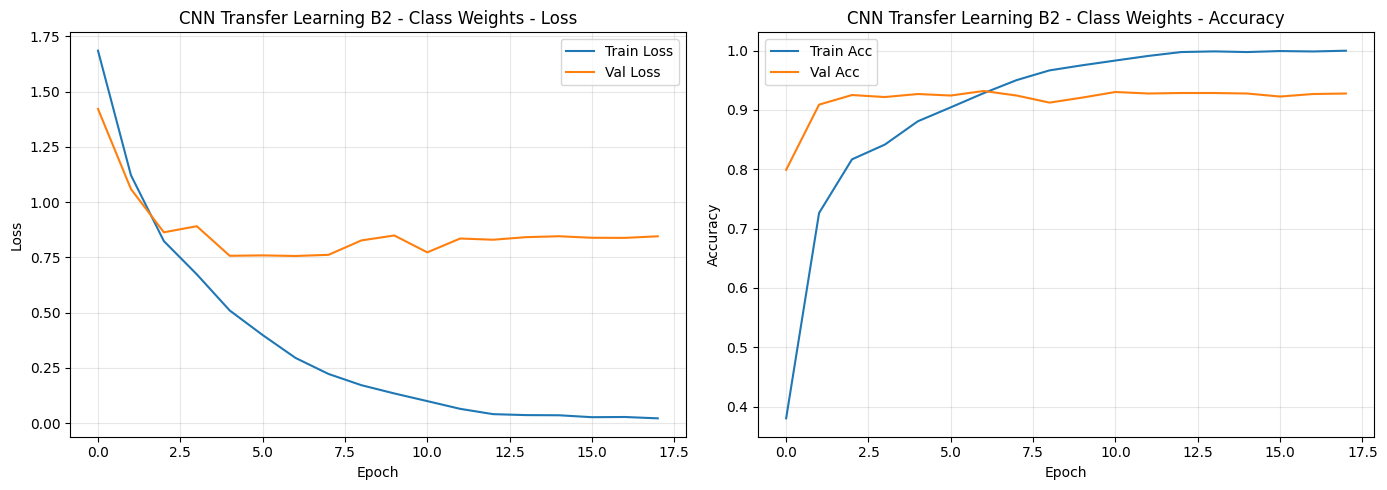

EVALUASI B2 - CLASS WEIGHTS


Test Loss: 0.7911
Test Accuracy: 0.9318
Test Macro F1: 0.1772
Test Weighted F1: 0.9298

Classification Report:
              precision    recall  f1-score   support

     neutral       0.97      0.97      0.97      1588
       happy       0.25      0.30      0.27        10
         sad       0.00      0.00      0.00        38
       angry       0.00      0.00      0.00        13
     fearful       0.00      0.00      0.00         1
   disgusted       0.00      0.00      0.00         3
   surprised       0.00      0.00      0.00         3

    accuracy                           0.93      1656
   macro avg       0.17      0.18      0.18      1656
weighted avg       0.93      0.93      0.93      1656



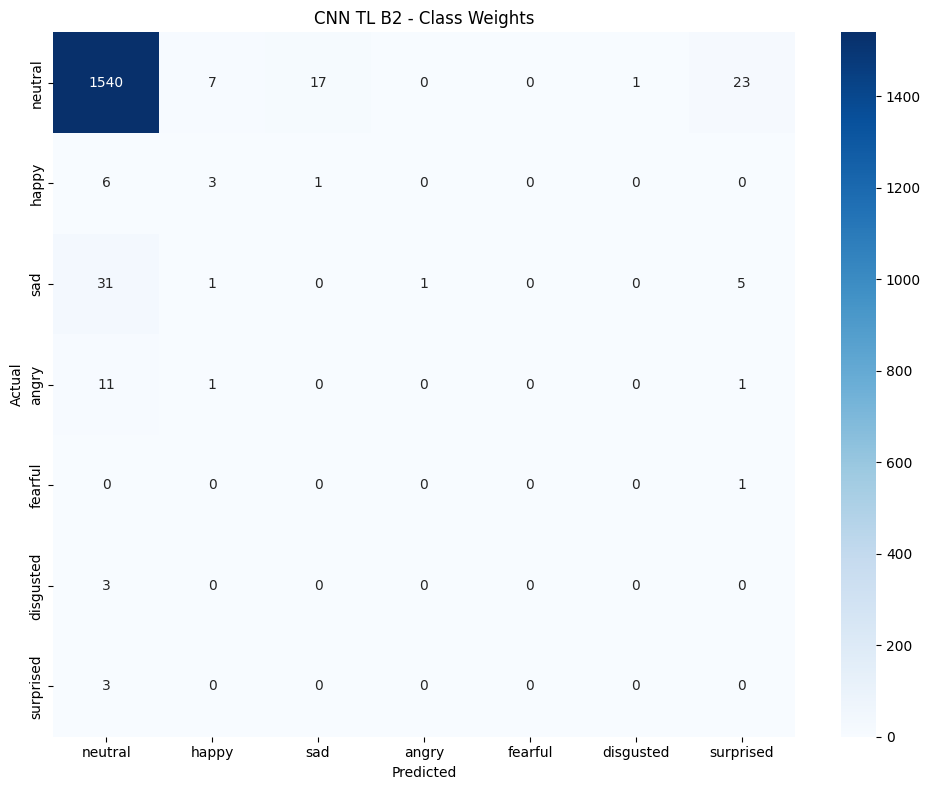

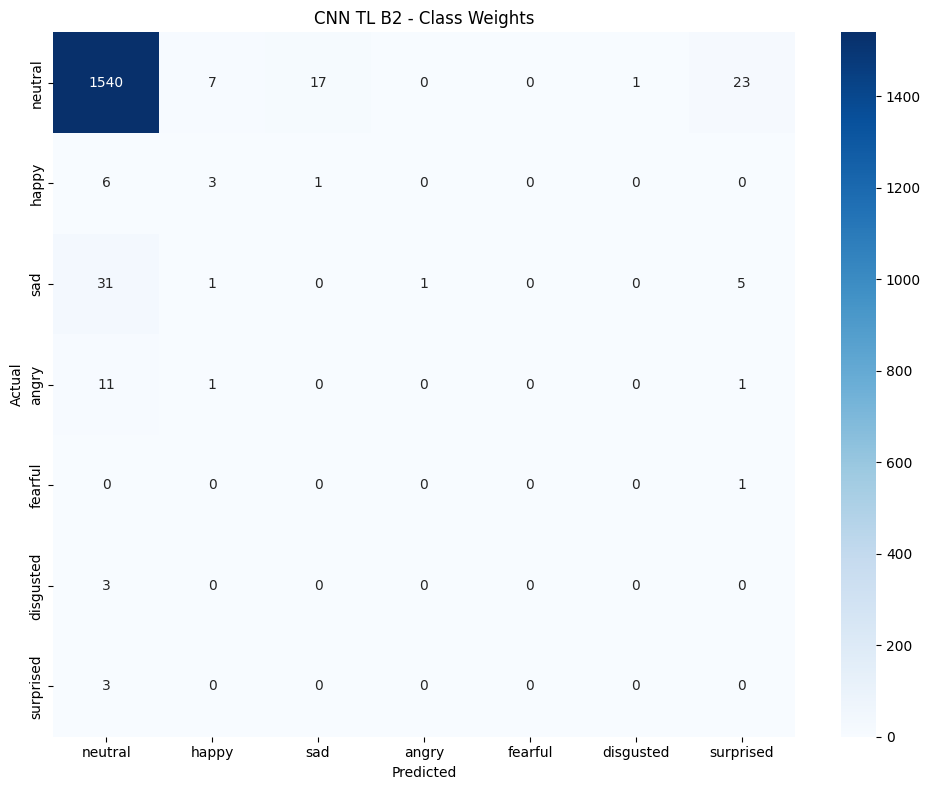

In [7]:
plot_training_history(history_b2, "CNN Transfer Learning B2 - Class Weights")

print("=" * 60)
print("EVALUASI B2 - CLASS WEIGHTS")
print("=" * 60)
results_b2 = full_evaluation(model_b2, test_loader, criterion_b2, device, "cnn")
plot_confusion_matrix(results_b2["confusion_matrix"], "CNN TL B2 - Class Weights")

## 6. Skenario B3: Class Weights + Augmentasi

In [8]:
# B3: Class weights + augmented data
train_loader_aug, _, _ = load_dataloaders(DATASET_AUG_DIR, BATCH_SIZE)
weights_aug = get_class_weights(DATASET_AUG_DIR, device)
print(f"Augmented class weights: {weights_aug}")

model_b3 = EmotionCNNTransfer(num_classes=NUM_CLASSES, pretrained=True).to(device)
criterion_b3 = nn.CrossEntropyLoss(weight=weights_aug)
optimizer_b3 = torch.optim.Adam(model_b3.parameters(), lr=LR)
scheduler_b3 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_b3, mode="max", factor=0.5, patience=8, min_lr=1e-7
)

print("\nTraining B3 (class weights + augmentation)...")
history_b3, best_epoch_b3 = train_model(
    model_b3, train_loader_aug, val_loader, criterion_b3, optimizer_b3, scheduler_b3,
    device, model_type="cnn", epochs=EPOCHS, patience=PATIENCE,
    save_path=str(OUTPUT_DIR / "cnn_tl_b3_augmented.pth")
)

Train: 7519 | Val: 1174 | Test: 1656
Train distribution:
     neutral: 5678
       happy: 751
         sad: 490
       angry: 150
     fearful: 150
   disgusted: 150
   surprised: 150
Augmented class weights: tensor([1.0000, 1.8865, 2.5717, 7.1514, 7.1514, 7.1514, 7.1514],
       device='cuda:0')



Training B3 (class weights + augmentation)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      1.2520     0.6253     1.0161    0.8918   0.2039   0.000050  (26.8s)


     2      0.7074     0.8133     0.8114    0.9089   0.2157   0.000050  (27.2s)


     3      0.4739     0.8726     0.7328    0.9046   0.2277   0.000050  (26.9s)


...

    22      0.0123     0.9991     0.6714    0.9259   0.2049   0.000025  (26.9s)


    23      0.0080     0.9999     0.6727    0.9259   0.2078   0.000025  (26.7s)


    24      0.0068     0.9996     0.6746    0.9267   0.2039   0.000025  (26.8s)


    25      0.0054     0.9999     0.7135    0.9267   0.2214   0.000025  (26.6s)


    26      0.0052     1.0000     0.7270    0.9284   0.2060   0.000025  (26.6s)

Early stopping at epoch 26. Best epoch: 11 (val_f1=0.2387)

Best: epoch 11, val_acc=0.9191, val_f1=0.2387
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/cnn_transfer/cnn_tl_b3_augmented.pth


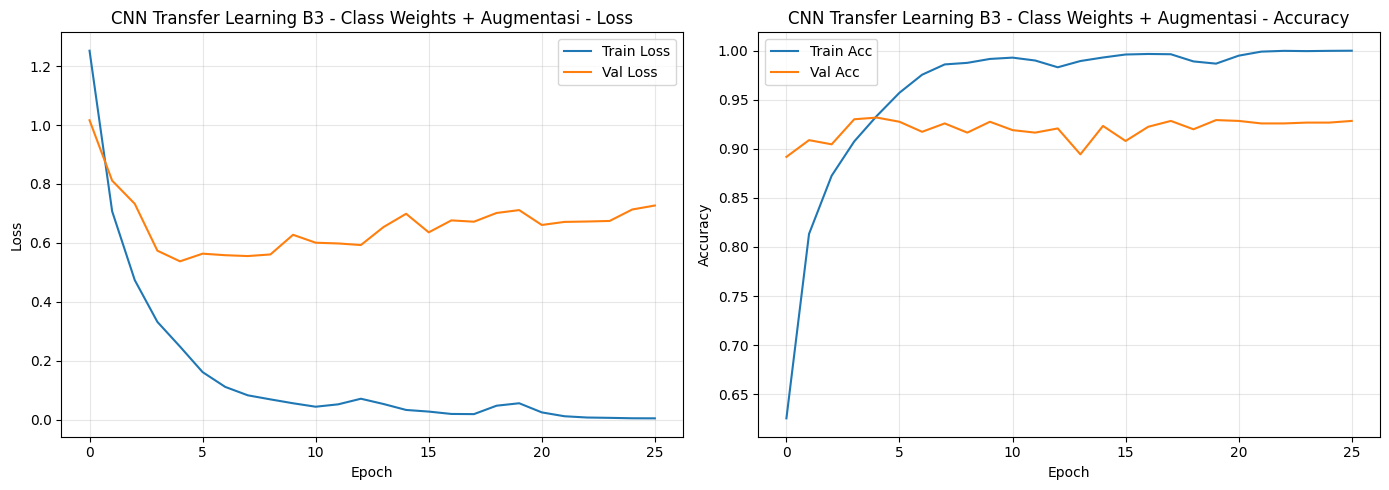

EVALUASI B3 - CLASS WEIGHTS + AUGMENTASI


Test Loss: 0.5041
Test Accuracy: 0.9366
Test Macro F1: 0.1629
Test Weighted F1: 0.9361

Classification Report:
              precision    recall  f1-score   support

     neutral       0.97      0.97      0.97      1588
       happy       0.06      0.20      0.10        10
         sad       0.11      0.05      0.07        38
       angry       0.00      0.00      0.00        13
     fearful       0.00      0.00      0.00         1
   disgusted       0.00      0.00      0.00         3
   surprised       0.00      0.00      0.00         3

    accuracy                           0.94      1656
   macro avg       0.16      0.18      0.16      1656
weighted avg       0.94      0.94      0.94      1656



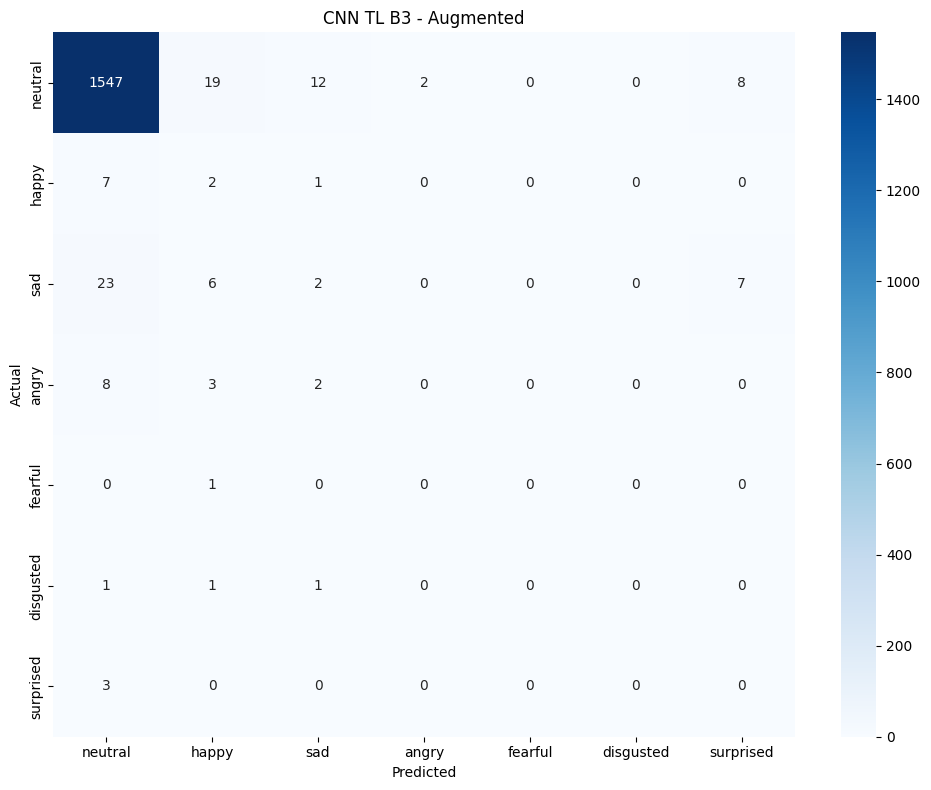

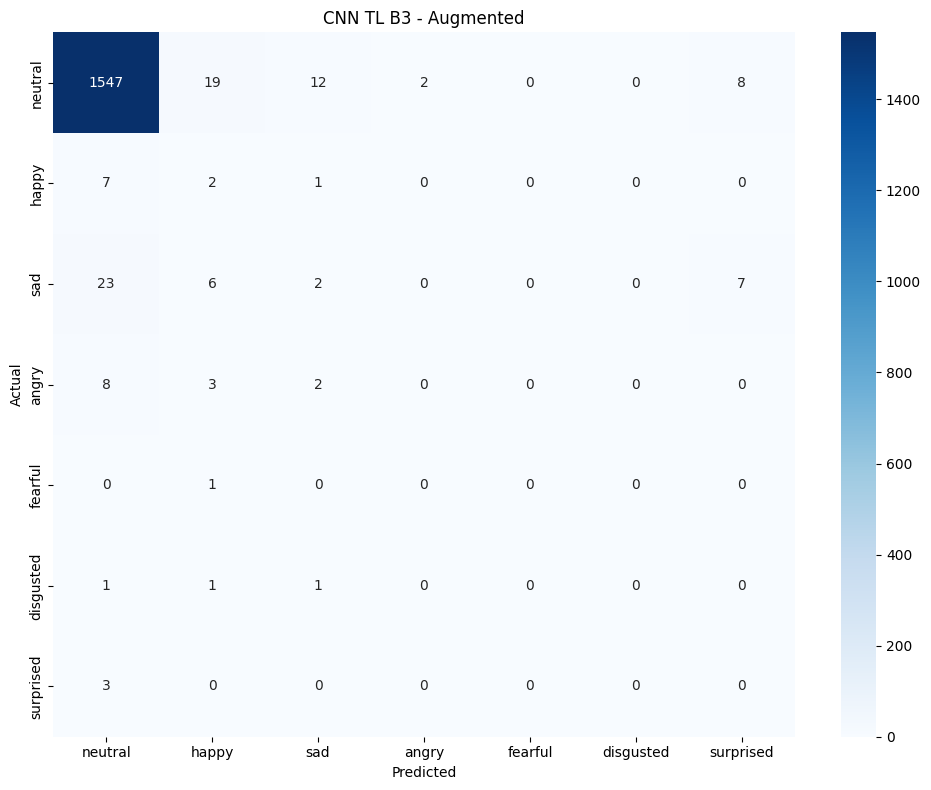

In [9]:
plot_training_history(history_b3, "CNN Transfer Learning B3 - Class Weights + Augmentasi")

print("=" * 60)
print("EVALUASI B3 - CLASS WEIGHTS + AUGMENTASI")
print("=" * 60)
results_b3 = full_evaluation(model_b3, test_loader, criterion_b3, device, "cnn")
plot_confusion_matrix(results_b3["confusion_matrix"], "CNN TL B3 - Augmented")

## 7. Perbandingan 3 Skenario

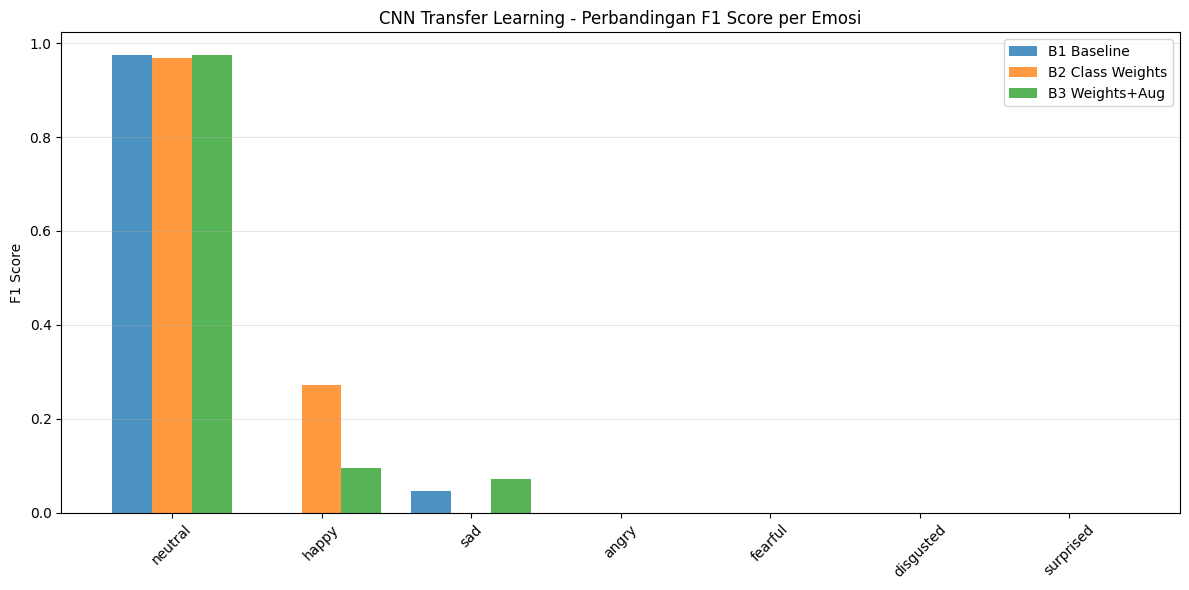

RINGKASAN CNN TRANSFER LEARNING (ResNet18) - 3 SKENARIO
Skenario                    Accuracy   Macro F1  Weighted F1
----------------------------------------------------------------------
B1 Baseline                   0.9499     0.1458       0.9353
B2 Class Weights              0.9318     0.1772       0.9298
B3 Weights+Aug                0.9366     0.1629       0.9361

Results saved to /home/bs000716/MOTHER-TANK/TRAIN/models/cnn_transfer/cnn_transfer_results.json


In [10]:
# Perbandingan per-class F1 score
all_results = {
    "B1 Baseline": results_b1,
    "B2 Class Weights": results_b2,
    "B3 Weights+Aug": results_b3,
}
plot_per_class_f1(all_results, "CNN Transfer Learning - Perbandingan F1 Score per Emosi")

# Summary table
print("=" * 70)
print("RINGKASAN CNN TRANSFER LEARNING (ResNet18) - 3 SKENARIO")
print("=" * 70)
print(f"{'Skenario':<25} {'Accuracy':>10} {'Macro F1':>10} {'Weighted F1':>12}")
print("-" * 70)
for name, r in all_results.items():
    print(f"{name:<25} {r['test_accuracy']:>10.4f} {r['test_macro_f1']:>10.4f} {r['test_weighted_f1']:>12.4f}")

# Save results
cnn_tl_results = {}
for name, r in all_results.items():
    cnn_tl_results[name] = {
        "accuracy": float(r["test_accuracy"]),
        "macro_f1": float(r["test_macro_f1"]),
        "weighted_f1": float(r["test_weighted_f1"]),
    }
with open(OUTPUT_DIR / "cnn_transfer_results.json", "w") as f:
    json.dump(cnn_tl_results, f, indent=2)
print(f"\nResults saved to {OUTPUT_DIR / 'cnn_transfer_results.json'}")